In [1]:
import sys

In [2]:
print(sys.executable)

/home/simonque/Documents/code/env/bin/python3


In [3]:
print(sys.prefix)

/home/simonque/Documents/code/env


Newton's Method
===================================

# Import Libraries

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import argparse
import csv

In [5]:
# parser = argparse.ArgumentParser(
#     description = "Perform regularized linear model regression from scratch.")
# parser.add_argument("filepath", type=str, help="Path to the input file")
# parser.add_argument("lambda_val", type=float, help="Lambda value used for LSE and Steepest Descent")
# parser.add_argument("num_polynomial_bases", type=int, help="Number of polynomial bases")
# args = parser.parse_args()

# Define input filename and parameters

In [6]:
filename = "input.txt"
num_polynomial_bases = 8

# Read the input file and store input data points into a list 

In [7]:
datapoints = []
with open(filename, 'r', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    for row in csv_reader:
        datapoints.append([float(i) for i in row])
num_datapoints = len(datapoints)
print(f"number of datapoints: {num_datapoints}\n")

datapoints_arr = np.zeros((num_datapoints, 2), dtype=np.float64)

i = 0
for datapoint in datapoints:
    datapoints_arr[i,0] = datapoint[0]
    datapoints_arr[i,1] = datapoint[1]
    i+=1;

print(datapoints_arr)

number of datapoints: 23

[[-5.         51.76405235]
 [-4.79591837 45.42306433]
 [-4.59183673 41.2744481 ]
 [-3.97959184 26.6362165 ]
 [-3.57142857 20.25680606]
 [-2.95918367 11.61842924]
 [-2.75510204 10.45052507]
 [-1.73469388  1.84809823]
 [-1.32653061 -1.04053496]
 [-0.91836735 -4.6146308 ]
 [-0.71428571 -1.38719773]
 [-0.30612245 -1.9916444 ]
 [ 0.10204082 -0.91292461]
 [ 0.71428571  6.63482003]
 [ 1.12244898  9.54686746]
 [ 1.73469388 15.72016147]
 [ 1.93877551 20.62251684]
 [ 2.55102041 33.48059726]
 [ 2.95918367 40.76391966]
 [ 3.97959184 66.89976056]
 [ 4.3877551  78.44316466]
 [ 4.59183673 86.99156782]
 [ 5.         99.78725972]]


# DIY matrix functions

## Matrix Transpose

In [8]:
def diy_transpose(input_matrix: np.array):
    if len(input_matrix.shape) == 1:
        input_matrix = np.expand_dims(input_matrix, -1)
    transposed_shape = input_matrix.shape[::-1]
    transposed_matrix = np.zeros(shape=transposed_shape, dtype=input_matrix.dtype)
    for i in range(transposed_shape[0]):
        for j in range(transposed_shape[1]):
            transposed_matrix[i,j] = input_matrix[j,i]
    return np.squeeze(transposed_matrix)

## Matrix multiplication

In [9]:
def diy_dot(A: np.array, B: np.array):
    if len(A.shape) == 1:
        A = np.expand_dims(A, 0)
    if len(B.shape) == 1:
        B = np.expand_dims(B, -1)
    # print(A.shape, B.shape)
    
    if (A.shape[1] != B.shape[0]):
        raise ValueError("A and B shapes do not fit for multiplication!")
    else:
        
        
        m = A.shape[0]
        t = A.shape[1]
        n = B.shape[1]
        
        C = np.zeros(shape=(m,n), dtype=A.dtype)
        # for each row in A
        for i in range(m):
            # for each column in B
            for j in range(n):
                for k in range(t):
                    C[i,j] += A[i,k] * B[k,j]
        return np.squeeze(C)
                

## Matrix abs

In [10]:
def diy_abs(A: np.array):
    A_abs = np.zeros(shape=A.shape, dtype=A.dtype)
    if len(A.shape) == 1:
        for i in range(A.shape[0]):
            if A[i] < 0:
                A_abs[i] = A[i] * -1
            else:
                A_abs[i] = A[i]
    else:
        for i in range(A.shape[0]):
            A[i] = diy_abs(A[i])
            
    return A_abs

## Matrix sum

In [11]:
def diy_sum(A:np.array):
    sum = 0
    if len(A.shape) == 1:
        for i in range(A.shape[0]):
            sum += A[i]
    else:
        for i in range(A.shape[0]):
            sum += diy_sum(A[i])
    return sum
    

## DIY argmax

In [12]:
def diy_argmax(A:np.array):
    argmax = 0
    if len(A.shape) == 1:
        maxval = A[0]
        for i in range(A.shape[0]):
            if A[i] > maxval:
               argmax = i 
    else:
        argmax = diy_argmax(A[i])
    return argmax

# Newton's Method

## Create A and b

In [13]:
b = np.zeros((num_datapoints), dtype=np.float32)
b = datapoints_arr[:,1]
    
A = np.zeros((num_datapoints, num_polynomial_bases), dtype=np.float32)
for basis in range(num_polynomial_bases):
    A[:,basis] = datapoints_arr[:,0] ** basis


In [14]:
A

array([[ 1.00000000e+00, -5.00000000e+00,  2.50000000e+01,
        -1.25000000e+02,  6.25000000e+02, -3.12500000e+03,
         1.56250000e+04, -7.81250000e+04],
       [ 1.00000000e+00, -4.79591846e+00,  2.30008335e+01,
        -1.10310120e+02,  5.29038330e+02, -2.53722461e+03,
         1.21683223e+04, -5.83582773e+04],
       [ 1.00000000e+00, -4.59183693e+00,  2.10849648e+01,
        -9.68187180e+01,  4.44575745e+02, -2.04141919e+03,
         9.37386328e+03, -4.30432500e+04],
       [ 1.00000000e+00, -3.97959185e+00,  1.58371515e+01,
        -6.30253983e+01,  2.50815353e+02, -9.98142761e+02,
         3.97220068e+03, -1.58077373e+04],
       [ 1.00000000e+00, -3.57142854e+00,  1.27551022e+01,
        -4.55539360e+01,  1.62692627e+02, -5.81045105e+02,
         2.07516113e+03, -7.41128955e+03],
       [ 1.00000000e+00, -2.95918369e+00,  8.75676823e+00,
        -2.59128857e+01,  7.66809845e+01, -2.26913116e+02,
         6.71477600e+02, -1.98702551e+03],
       [ 1.00000000e+00, -2.755102

In [15]:
b

array([51.76405235, 45.42306433, 41.2744481 , 26.6362165 , 20.25680606,
       11.61842924, 10.45052507,  1.84809823, -1.04053496, -4.6146308 ,
       -1.38719773, -1.9916444 , -0.91292461,  6.63482003,  9.54686746,
       15.72016147, 20.62251684, 33.48059726, 40.76391966, 66.89976056,
       78.44316466, 86.99156782, 99.78725972])

## LU decomposition

In [16]:
def transpose(input_matrix: np.array):
    transposed_shape = input_matrix.shape[::-1]
    transposed_matrix = np.zeros(shape=transposed_shape, dtype=input_matrix.dtype)
    for i in range(transposed_shape[0]):
        for j in range(transposed_shape[1]):
            transposed_matrix[i,j] = input_matrix[j,i]
    return transposed_matrix

In [17]:
A_t = transpose(A)
print(A_t.shape)
print(A_t)

(8, 23)
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00]
 [-5.00000000e+00 -4.79591846e+00 -4.59183693e+00 -3.97959185e+00
  -3.57142854e+00 -2.95918369e+00 -2.75510216e+00 -1.73469388e+00
  -1.32653058e+00 -9.18367326e-01 -7.14285731e-01 -3.06122452e-01
   1.02040820e-01  7.14285731e-01  1.12244892e+00  1.73469388e+00
   1.93877554e+00  2.55102038e+00  2.95918369e+00  3.97959185e+00
   4.38775492e+00  4.59183693e+00  5.00000000e+00]
 [ 2.50000000e+01  2.30008335e+01  2.10849648e+01  1.58371515e+01
   1.27551022e+01  8.75676823e+00  7.59058714e+00  3.00916290e+00
   1.75968349e+00  8.43398571e-01  5.10204077e-01  9.37109515e-02
   1.04123279e-02  5.10204077e-0

In [18]:
'''
Source: https://www.scicoding.com/how-to-calculate-lu-decomposition-in-python/
'''
def lu_decomposition(input_matrix: np.array):
    input_shape = input_matrix.shape
    # create lower and upper matrices 
    L = np.zeros(shape=(input_shape), dtype=np.float32)
    U = np.zeros(shape=(input_shape), dtype=np.float32)
        
    # calculate the U matrix
    for i in range(input_shape[0]):
        for j in range(i, input_shape[0]):
            lu_sum = 0
            for k in range(i):
                lu_sum += L[i,k] * U[k,j]
            U[i,j] = input_matrix[i,j] - lu_sum

        for j in range(i, input_shape[0]):
            # initialize L diagonal to 1
            if (i == j):
                L[i,i] = 1
            else:
                lu_sum = 0
                for k in range(i):
                    lu_sum += L[j,k] * U[k,i]
                L[j,i] = (input_matrix[j,i] - lu_sum) / U[i,i]
            
    return L, U
# L, U = lu_decomposition(A)

# print("L: \n", L)
# print("U: \n", U)

## Define learning rate

In [19]:
learning_rate = 0.0001

## Initialize weights, biases

In [20]:
x = np.zeros(shape=num_polynomial_bases, dtype=np.float32)
# x = np.array([-0.2314002,  4.90619  ,  3.0238533])

## Define error function

In [21]:
def compute_error(A, x, b):
    Ax = diy_dot(A, x)
    error = diy_sum(diy_abs(Ax - b) ** 2)
    return error

## Compute the gradient

In [22]:
x_t = diy_transpose(x)
grad = 2 * (diy_dot(x_t, diy_dot(A_t, A))-diy_dot(A_t, b))
grad

array([-1.3164307e+03, -1.7875270e+03, -2.3366104e+04, -2.9995133e+04,
       -4.7620503e+05, -5.8705225e+05, -1.0293932e+07, -1.2165932e+07],
      dtype=float32)

## Computing for the Hessian (second-order derivative of the LSE)

In [23]:
hessian = 2 * diy_dot(A_t, A)
hessian

array([[ 4.6000000e+01, -7.1428604e+00,  4.5045816e+02, -1.4027100e+02,
         7.9893218e+03, -3.0364453e+03,  1.6298686e+05, -6.9726062e+04],
       [-7.1428604e+00,  4.5045819e+02, -1.4027100e+02,  7.9893218e+03,
        -3.0364463e+03,  1.6298686e+05, -6.9726062e+04,  3.5266935e+06],
       [ 4.5045816e+02, -1.4027100e+02,  7.9893218e+03, -3.0364453e+03,
         1.6298686e+05, -6.9726062e+04,  3.5266938e+06, -1.6764060e+06],
       [-1.4027100e+02,  7.9893218e+03, -3.0364453e+03,  1.6298686e+05,
        -6.9726062e+04,  3.5266938e+06, -1.6764065e+06,  7.8839664e+07],
       [ 7.9893218e+03, -3.0364463e+03,  1.6298686e+05, -6.9726062e+04,
         3.5266935e+06, -1.6764065e+06,  7.8839664e+07, -4.1024360e+07],
       [-3.0364453e+03,  1.6298686e+05, -6.9726062e+04,  3.5266938e+06,
        -1.6764065e+06,  7.8839672e+07, -4.1024360e+07,  1.8000933e+09],
       [ 1.6298686e+05, -6.9726062e+04,  3.5266938e+06, -1.6764065e+06,
         7.8839664e+07, -4.1024360e+07,  1.8000933e+09, -1

## Decompose Hessian matrix with LU decomposition

In [24]:
L,U = lu_decomposition(hessian)
L,U

(array([[ 1.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-1.5527958e-01,  1.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 9.7925692e+00, -1.5650204e-01,  1.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-3.0493696e+00,  1.7731295e+01, -1.1658966e-01,  1.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 1.7368091e+02, -3.9965985e+00,  2.3679764e+01, -1.7292967e-01,
          1.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-6.6009682e+01,  3.6166840e+02, -4.0809560e+00,  2.9861315e+01,
         -3.4447366e-01,  1.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 3.5431926e+03, -9.8848610e+01,  5.3927362e+02, -7.8893790e+00,
          3.6418518e+01,  3.4795085e-01,  1.0

## Forward Substitution

In [25]:
'''
Ax=b
solve for x
'''
def forward_sub(A: np.array, b: np.array):
    n = A.shape[0]
    x = np.zeros(shape=n, dtype=np.float32)
    for i in range(n):
        temp = 0
        for j in range(i):
            temp += A[i,j] * x[j]
        x[i] = (b[i] - temp) / A[i,i]
    return x

## Backward substitution

In [26]:
'''
Ax=b
solve for x
'''
def backward_sub(A: np.array, b: np.array):
    n = A.shape[0]
    x = np.zeros(shape=n, dtype=np.float32)
    for i in range(n-1,-1,-1):
        temp = 0
        for j in range(n-1,i,-1):
            temp += A[i,j] * x[j]
        x[i] = (b[i] - temp) / A[i,i]
    return x

In [27]:
'''
x_(n+1) = x_n - H^-1 g
x_(n+1) - x_n = -H^-1 g
x_(n+1) - x_n = -(LU)^-1 g
LU (x_(n+1) - x_n) = -g
t = (x_(n+1) - x_n)
LUt = -g
combine Ut into a temp z
Lz = -g
Solve with forward substitution
'''
z = forward_sub(L, -grad)
z

array([ 1316.4307  ,  1991.9418  , 10786.608   ,   -52.683594,
          93.65625 ,  -847.8125  ,  6000.      , -6549.      ],
      dtype=float32)

In [28]:
'''
Ut = z
Solve for t with backward substitution.
'''
x = backward_sub(U, z)
x

array([-5.9119183e-01,  4.9531898e+00,  3.3605313e+00, -5.0807104e-02,
       -3.9502297e-02,  6.1382200e-03,  1.1055931e-03, -1.7407480e-04],
      dtype=float32)

## Calculate the total error

In [29]:
# regressed_y_vals = np.zeros(shape=(num_datapoints), dtype=np.float32)
# for d_idx in range(num_datapoints):
#     for basis in range(num_polynomial_bases):
#         regressed_y_vals[d_idx] += x[basis] * datapoints_arr[d_idx,0] ** basis
# regressed_y_vals

In [30]:
def compute_error(A, x, b):
    Ax = diy_dot(A, x)
    error = diy_sum(diy_abs(Ax - b) ** 2)
    return error

In [31]:
error = compute_error(A, x, b)
print(f"Total error: {error}")

Total error: 22.23199176520823


# Print equation of curve

In [32]:
equation = ""
if x[-1] < -1:
    equation += "-"
for i in range(num_polynomial_bases-1,-1,-1):
    equation += f"{abs(x[i]):.8f} "
    if i > 0:
        equation += f"x ^ {i} "
        if x[i-1] < 0:
            equation += "- "
        else:
            equation += "+ "
print(f"Curve of best fit: {equation}")
       

Curve of best fit: 0.00017407 x ^ 7 + 0.00110559 x ^ 6 + 0.00613822 x ^ 5 - 0.03950230 x ^ 4 - 0.05080710 x ^ 3 + 3.36053133 x ^ 2 + 4.95318985 x ^ 1 - 0.59119183 


# Visualization

In [33]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

In [34]:
'''
Function to visualize the datapoints and the regressed trendline
'''
def plot_datapoints_trendline(datapoints_arr: np.array, 
                              num_bases: int,
                              equation: str,
                                error: float,
                             filename: str):
    # get min and max x and y values of the sample data 
    min_x = np.min(datapoints_arr[:,0])
    max_x = np.max(datapoints_arr[:,0])
    min_y = np.min(datapoints_arr[:,1])
    max_y = np.max(datapoints_arr[:,1])
    x_bounds = (math.floor(min_x - 1), math.ceil(max_x + 1))
    y_bounds = (math.floor(min_y - 1), math.ceil(max_y + 1))

    fig,ax = plt.subplots(figsize = (10,6))
    # set limits
    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])
    # plot curve
    curve_x = np.linspace(min_x, max_x, 1000)
    curve_y = 0
    for i in range(num_bases):
        curve_y += x[i] * curve_x ** i
    ax.plot(curve_x, curve_y, label="trendline", color=((0.0,0.0, 1.0)))
    # plot points
    ax.scatter(datapoints_arr[:,0], datapoints_arr[:,1], label="datapoints", s=80, c=[[1.0,0.0, 0.0]], marker="X")
    ax.text(min_x - 0.5, max_y-15, f"equation = {equation}")
    ax.text(min_x - 0.5, max_y-20, f"no. datapoints = {datapoints_arr.shape[0]}")
    ax.text(min_x - 0.5, max_y-25, f"num_bases = {num_bases}")
    ax.text(min_x - 0.5, max_y-30, f"error = {error:.4f}")
    ax.legend(loc="upper left")
    plt.title(filename,fontsize=16, fontweight='bold')
    fig.savefig(filename)
    plt.show()

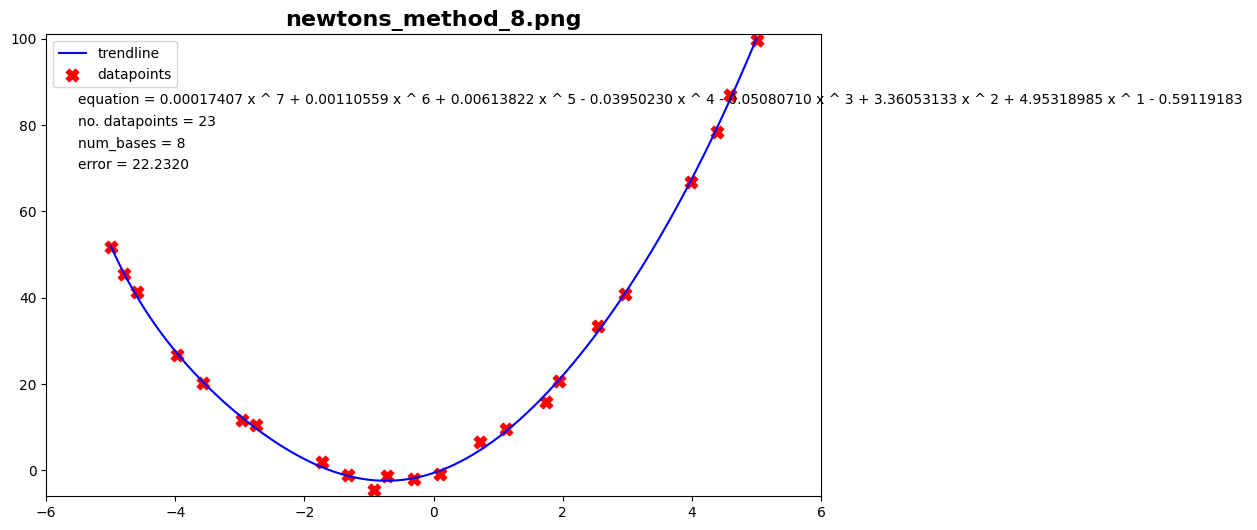

In [35]:
plot_datapoints_trendline(datapoints_arr, 
                          num_polynomial_bases, 
                          equation,
                          error,
                          f"newtons_method_{num_polynomial_bases}.png")